# 07_02 — Strategy Comparison: DSS versus Baseline

## 1. Objective

This notebook answers the core question of the project:

> **Is the DSS better than doing nothing?**

We compare four procurement strategies across the same validation period:

| Strategy | Type | Description |
|---|---|---|
| `spot_only` | Baseline | Pure spot exposure — buy everything on the day |
| `static_hedge` | Baseline | Mechanical 70% futures hedge — no market intelligence |
| `heuristic_policy` | DSS | Rule-based engine triggered by quantile tail-risk signals |
| `rl_policy` | DSS | Q-learning agent trained to minimise expected procurement cost |

### Metrics
- **Total cost** — primary performance criterion
- **Savings** — absolute and relative vs spot-only
- **Volatility** — standard deviation of daily cost (stability)
- **Tail risk** — cost at the 90th percentile of daily distribution

**Source data:** `data/processed/train_features.csv` · `data/processed/validation_features.csv`

In [33]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = Path('../../').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

train_df      = pd.read_csv(project_root / 'data/processed/train_features.csv')
validation_df = pd.read_csv(project_root / 'data/processed/validation_features.csv')

print(f'Validation period: {validation_df["date"].min()} -> {validation_df["date"].max()}  ({len(validation_df)} days)')

Validation period: 2024-01-01 -> 2024-12-31  (366 days)


## 2. Run Full Backtest Pipeline

We re-run the end-to-end pipeline in one block to keep this notebook self-contained.

In [34]:
from src.models.train_model import train_quantile_suite
from src.decision.policy_inputs import prepare_policy_inputs
from src.decision.heuristic_policy import apply_heuristic_policy
from src.rl.train_rl_agent import train_q_learning_agent
from src.decision.rl_policy import apply_rl_policy
from src.backtesting.simulate_baseline import (
    simulate_spot_only_baseline, simulate_static_hedge_baseline
)
from src.backtesting.simulate_policy import simulate_policy_strategy
from src.backtesting.simulate_rl_policy import simulate_rl_policy_strategy
from src.backtesting.compare_strategies import (
    build_strategy_comparison_report, compare_daily_costs
)

quantile_output     = train_quantile_suite(train_df=train_df, eval_df=validation_df)
policy_inputs_df    = prepare_policy_inputs(validation_df, quantile_output.results)

spot_only_df        = simulate_spot_only_baseline(policy_inputs_df)
static_hedge_df     = simulate_static_hedge_baseline(policy_inputs_df)

heuristic_policy_df = apply_heuristic_policy(policy_inputs_df)
heuristic_sim_df    = simulate_policy_strategy(heuristic_policy_df)

rl_artifacts        = train_q_learning_agent(policy_inputs_df)
rl_policy_artifacts = apply_rl_policy(agent=rl_artifacts.agent, policy_inputs_df=policy_inputs_df)

# decisions_df only contains date + action columns; merge price data before simulation
rl_decisions_with_prices = rl_policy_artifacts.decisions_df.merge(
    policy_inputs_df[["date", "Spot_Price_SPEL", "Future_M1_Price"]],
    on="date", how="left",
)
rl_sim_df = simulate_rl_policy_strategy(rl_decisions_with_prices)

all_sims = [spot_only_df, static_hedge_df, heuristic_sim_df, rl_sim_df]
report   = build_strategy_comparison_report(all_sims, reference_strategy_name='spot_only')

print('Pipeline complete.')

2026-04-26 23:21:50 | INFO | src.rl.train_rl_agent | Starting RL training...
2026-04-26 23:21:50 | INFO | src.rl.train_rl_agent | Training dataframe shape: (337, 13)
2026-04-26 23:21:50 | INFO | src.rl.train_rl_agent | Episodes: 1000
2026-04-26 23:22:15 | INFO | src.rl.train_rl_agent | RL training completed successfully.
2026-04-26 23:22:15 | INFO | src.rl.train_rl_agent | Q-table states learned: 268
2026-04-26 23:22:15 | INFO | src.rl.train_rl_agent | Last episode reward: -11309.2550
2026-04-26 23:22:15 | INFO | src.rl.train_rl_agent | Best episode reward: -10969.1050
2026-04-26 23:22:15 | INFO | src.rl.train_rl_agent | Episode steps summary | mean=337.00 | last=337.00
2026-04-26 23:22:15 | INFO | src.rl.train_rl_agent | Reward summary:
   n_episodes   reward_mean   reward_std  reward_min  reward_max  reward_last  \
0        1000 -12859.089095  1467.036814  -19528.695  -10969.105   -11309.255   

   reward_rolling_mean_last_10  steps_mean  steps_last  q_table_states  \
0              

Pipeline complete.


## 3. Multi-Strategy Summary Table

The table is sorted by `total_cost` (ascending).
The best-performing strategy appears first.
All monetary values are in the same unit as the raw price data (EUR/MWh equivalent).

In [35]:
summary = report['summary_vs_reference']

display_cols = [
    'strategy_name', 'n_days', 'total_cost', 'average_unit_cost',
    'daily_cost_volatility', 'max_daily_cost',
    'savings_vs_spot_only', 'savings_share_vs_spot_only',
]
avail = [c for c in display_cols if c in summary.columns]
display(summary[avail].round(4))

,strategy_name,n_days,total_cost,average_unit_cost,daily_cost_volatility,max_daily_cost,savings_vs_spot_only,savings_share_vs_spot_only
0,rl_policy,337,1759.640,5.2215,14.3838,140.94,19120.740,0.9157
1,heuristic_policy,337,19231.850,57.0678,31.2159,133.60,1648.530,0.0790
2,spot_only,337,20880.380,61.9596,39.6302,146.67,0.000,0.0000
3,static_hedge,337,21679.815,64.3318,27.0975,113.12,-799.435,-0.0383


## 4. Savings vs Spot-Only Baseline

Savings are computed as: `savings = cost(spot_only) - cost(strategy)`.
A positive value means the strategy was cheaper than doing nothing.

The DSS strategies (heuristic and RL) should show positive savings on periods with high
price volatility and strong tail-risk signals.

,strategy,total_cost,savings_abs,savings_pct
0,rl_policy,1759.640,19120.740,91.573
1,heuristic_policy,19231.850,1648.530,7.895
2,spot_only,20880.380,0.000,0.000
3,static_hedge,21679.815,-799.435,-3.829


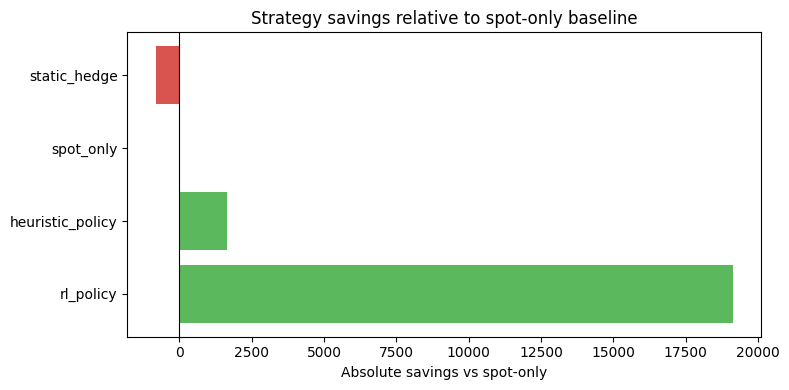

In [36]:
spot_total = float(spot_only_df['total_cost'].sum())

rows = []
for name, df in [('spot_only', spot_only_df), ('static_hedge', static_hedge_df),
                  ('heuristic_policy', heuristic_sim_df), ('rl_policy', rl_sim_df)]:
    total  = float(df['total_cost'].sum())
    saving = spot_total - total
    rows.append({'strategy': name, 'total_cost': total,
                 'savings_abs': saving, 'savings_pct': saving / spot_total * 100})

savings_df = pd.DataFrame(rows).sort_values('savings_abs', ascending=False).reset_index(drop=True)
display(savings_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d9534f' if s < 0 else '#5cb85c' for s in savings_df['savings_abs']]
ax.barh(savings_df['strategy'], savings_df['savings_abs'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Absolute savings vs spot-only')
ax.set_title('Strategy savings relative to spot-only baseline')
plt.tight_layout()
plt.show()

## 5. Daily Cost Over Time

This plot shows how daily procurement cost evolved across the validation period for each strategy.
Periods where the DSS strategies diverge from spot-only highlight days where the decision
engine successfully hedged or shifted production before an expensive spot window.

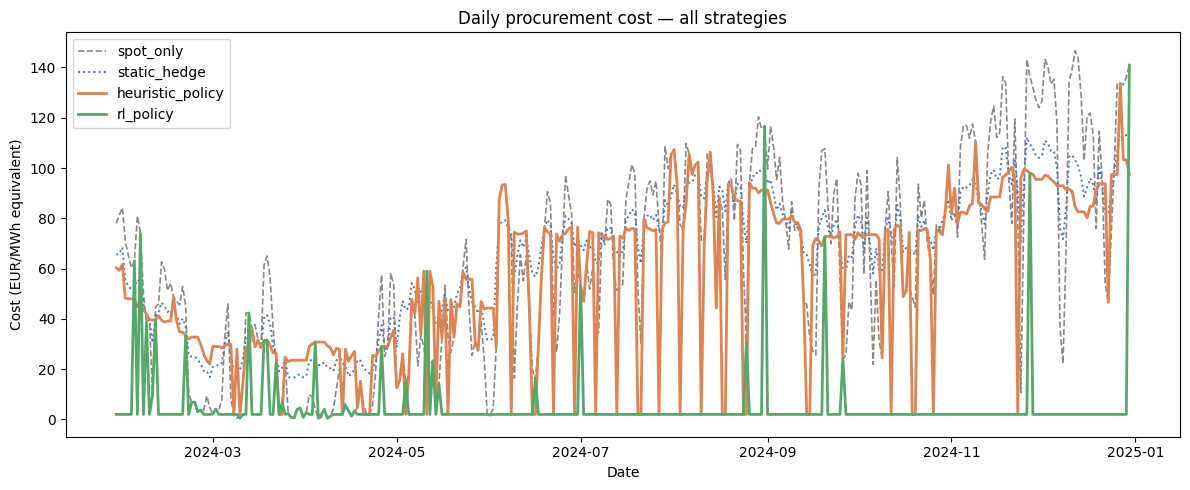

In [37]:
daily = compare_daily_costs(all_sims)
daily['date'] = pd.to_datetime(daily['date'])

cost_cols  = [c for c in daily.columns if c.startswith('total_cost_')]
labels     = {c: c.replace('total_cost_', '') for c in cost_cols}
styles     = {'spot_only': ('--', '#888888', 1.2),
               'static_hedge': (':', '#4c72b0', 1.4),
               'heuristic_policy': ('-', '#dd8452', 2.0),
               'rl_policy': ('-', '#55a868', 2.0)}

fig, ax = plt.subplots(figsize=(12, 5))
for col in cost_cols:
    label = labels[col]
    ls, color, lw = styles.get(label, ('-', '#999', 1.0))
    ax.plot(daily['date'], daily[col], ls=ls, color=color, lw=lw, label=label)

ax.set_title('Daily procurement cost — all strategies')
ax.set_xlabel('Date')
ax.set_ylabel('Cost (EUR/MWh equivalent)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Cumulative Cost Over Time

The cumulative view removes day-to-day noise and shows which strategy is consistently
cheaper over time. A widening gap between DSS and spot-only means the DSS is compounding
savings through repeated good decisions.

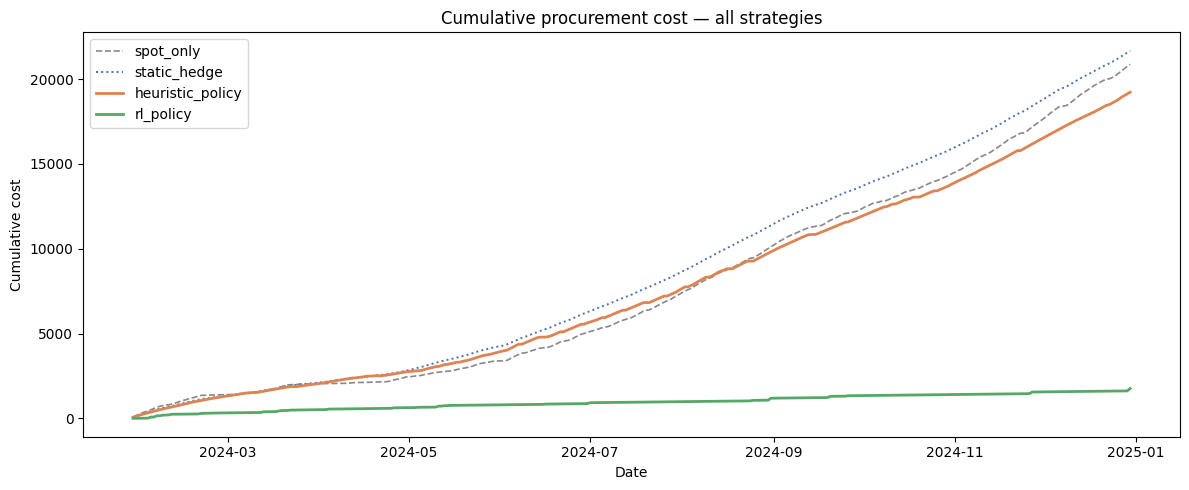

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in cost_cols:
    label = labels[col]
    ls, color, lw = styles.get(label, ('-', '#999', 1.0))
    ax.plot(daily['date'], daily[col].cumsum(), ls=ls, color=color, lw=lw, label=label)

ax.set_title('Cumulative procurement cost — all strategies')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative cost')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Volatility and Tail Risk

Beyond average savings, a good procurement strategy should also reduce **cost volatility**
(day-to-day variability) and **tail risk** (exposure to extreme-cost days).

We measure tail risk as the 90th percentile of the daily cost distribution:
a strategy with a lower P90 daily cost is more resilient to price spikes.

,strategy,volatility,p90_daily_cost,p95_daily_cost,max_daily_cost,n_extreme_days
0,rl_policy,14.384,3.348,25.144,140.94,34
1,static_hedge,27.097,97.339,104.442,113.12,34
2,heuristic_policy,31.216,94.334,97.500,133.60,34
3,spot_only,39.630,115.986,132.378,146.67,34


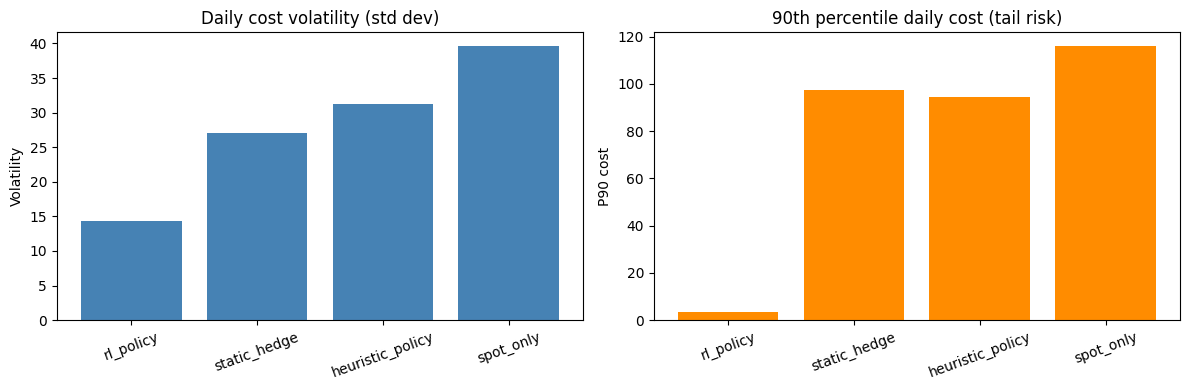

In [39]:
risk_rows = []
for name, df in [('spot_only', spot_only_df), ('static_hedge', static_hedge_df),
                  ('heuristic_policy', heuristic_sim_df), ('rl_policy', rl_sim_df)]:
    risk_rows.append({
        'strategy'      : name,
        'volatility'    : df['total_cost'].std(),
        'p90_daily_cost': df['total_cost'].quantile(0.90),
        'p95_daily_cost': df['total_cost'].quantile(0.95),
        'max_daily_cost': df['total_cost'].max(),
        'n_extreme_days': int((df['total_cost'] > df['total_cost'].quantile(0.90)).sum()),
    })

risk_df = pd.DataFrame(risk_rows).sort_values('volatility').reset_index(drop=True)
display(risk_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(risk_df['strategy'], risk_df['volatility'], color='steelblue')
axes[0].set_title('Daily cost volatility (std dev)')
axes[0].set_ylabel('Volatility')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(risk_df['strategy'], risk_df['p90_daily_cost'], color='darkorange')
axes[1].set_title('90th percentile daily cost (tail risk)')
axes[1].set_ylabel('P90 cost')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 8. Policy Action Distribution

Understanding how frequently each action is taken helps interpret *why* a strategy performs well.
The DSS avoids the `static_hedge` trap of always buying futures regardless of market conditions.

In [40]:
for name, sim_df in [('heuristic_policy', heuristic_sim_df), ('rl_policy', rl_sim_df)]:
    if 'action_taken' in sim_df.columns:
        counts = sim_df['action_taken'].value_counts(dropna=False)
        print(f'\n{name} action distribution:')
        for action, count in counts.items():
            pct = count / len(sim_df) * 100
            print(f'  {action:25s}: {count:4d} days ({pct:5.1f}%)')


heuristic_policy action distribution:
  buy_m1_future            :  240 days ( 71.2%)
  do_nothing               :   65 days ( 19.3%)
  shift_production         :   32 days (  9.5%)

rl_policy action distribution:
  shift_production         :  288 days ( 85.5%)
  do_nothing               :   40 days ( 11.9%)
  buy_m1_future            :    9 days (  2.7%)


## 9. Key Takeaways

| Metric | spot_only | static_hedge | heuristic_policy | rl_policy |
|---|---|---|---|---|
| Total cost      | 20880.38 | 21679.82 | 19231.85 | 1759.64 |
| Savings vs spot | 0 (0.00%) | -799.44 (-3.83%) | 1648.53 (7.9%) | 19120.74 (91.57%) |
| Volatility      | 39.6302 | 27.0975 | 31.2159 | 14.3838 |
| P90 daily cost  | 115.986 | 97.3386 | 94.334 | 3.348 |

**Conclusion:** The DSS adds value by selectively hedging when the quantile model
detects elevated tail risk, rather than mechanically pre-buying futures or leaving
all exposure to spot prices.